# Introduction

<center><img src="https://i.imgur.com/9hLRsjZ.jpg" height=400></center>

This dataset was scraped from [nextspaceflight.com](https://nextspaceflight.com/launches/past/?page=1) and includes all the space missions since the beginning of Space Race between the USA and the Soviet Union in 1957!

### Install Package with Country Codes

In [ ]:
%pip install iso3166

### Upgrade Plotly

Run the cell below if you are working with Google Colab.

In [ ]:
%pip install --upgrade plotly

### Import Statements

In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# These might be helpful:
from iso3166 import countries
from datetime import datetime, timedelta

### Notebook Presentation

In [ ]:
#set all float data to display only 2 decimal places
pd.options.display.float_format = '{:,.2f}'.format

### Load the Data

In [ ]:
df_data = pd.read_csv('mission_launches.csv')

# Preliminary Data Exploration

* What is the shape of `df_data`?
* How many rows and columns does it have?
* What are the column names?
* Are there any NaN values or duplicates?

In [ ]:
#check the shape of the data. There are 4324 rows and 9 columns
df_data.shape

(4324, 9)

In [ ]:
#View the first 5 rows of data and the column  names
df_data.head()

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


In [ ]:
#view the last 5 rows of data
df_data.tail()

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
4319,4319,4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Wed Feb 05, 1958 07:33 UTC",Vanguard | Vanguard TV3BU,StatusRetired,NaN,Failure
4320,4320,4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA","Sat Feb 01, 1958 03:48 UTC",Juno I | Explorer 1,StatusRetired,NaN,Success
4321,4321,4321,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Fri Dec 06, 1957 16:44 UTC",Vanguard | Vanguard TV3,StatusRetired,NaN,Failure
4322,4322,4322,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Sun Nov 03, 1957 02:30 UTC",Sputnik 8K71PS | Sputnik-2,StatusRetired,NaN,Success
4323,4323,4323,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Fri Oct 04, 1957 19:28 UTC",Sputnik 8K71PS | Sputnik-1,StatusRetired,NaN,Success


In [ ]:
#View 5 random rows of data
df_data.sample(50)

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
2804,2804,2804,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Tue Jul 06, 1976 12:08 UTC",Soyuz | Soyuz 21,StatusRetired,NaN,Success
1595,1595,1595,Arianespace,"ELA-2, Guiana Space Centre, French Guiana, France","Sat Dec 18, 1993 01:27 UTC","Ariane 44L | DBS-1, Thaicom-1",StatusRetired,NaN,Success
2412,2412,2412,RVSN USSR,"Site 90/20, Baikonur Cosmodrome, Kazakhstan","Sat Mar 21, 1981 03:45 UTC",Tsyklon-2 | Cosmos 1266,StatusRetired,NaN,Success
542,542,542,Arianespace,"ELS, Guiana Space Centre, French Guiana, France","Fri Aug 22, 2014 12:27 UTC",Soyuz ST-B/Fregat-MT | Galileo FOC FM01-FM02,StatusActive,NaN,Partial Failure
641,641,641,ULA,"SLC-37B, Cape Canaveral AFS, Florida, USA","Fri Jun 29, 2012 13:15 UTC",Delta IV Heavy | NROL-15,StatusActive,350.0,Success
799,799,799,Kosmotras,"Site 370/13, Yasny Cosmodrome, Russia","Wed Oct 01, 2008 06:37 UTC",Dnepr | THEOS 1,StatusRetired,29.0,Success
976,976,976,ILS,"SLC-41, Cape Canaveral AFS, Florida, USA","Fri Dec 17, 2004 12:07 UTC",Atlas V 521 | AMC-16,StatusActive,135.0,Success
1712,1712,1712,MHI,"LA-Y1, Tanegashima Space Center, Japan","Tue Feb 11, 1992 01:50 UTC",H-I (9 SO) | JERS 1,StatusRetired,NaN,Success
2011,2011,2011,MHI,"LA-Y1, Tanegashima Space Center, Japan","Thu Feb 19, 1987 01:23 UTC",N-II | Momo 1a,StatusRetired,NaN,Success
1872,1872,1872,Martin Marietta,"SLC-40, Cape Canaveral AFS, Florida, USA","Mon Sep 04, 1989 05:54 UTC",Titan 34D | DSCS-II-16 & DSCS-III-A2,StatusRetired,NaN,Success


## Data Cleaning - Check for Missing Values and Duplicates

Consider removing columns containing junk data.

In [ ]:
#check to see if the data contains any missing (nan) values
df_data.isna().values.any()

np.True_

In [ ]:
#check to see how many missing values the data contains
df_data.isna().values.sum()

np.int64(3360)

In [ ]:
#check to see if the data contains any duplicate rows
df_data.duplicated().values.any()

np.False_

In [ ]:
#view details about the data. See that Price is the only column with missing values
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0.1    4324 non-null   int64 
 1   Unnamed: 0      4324 non-null   int64 
 2   Organisation    4324 non-null   object
 3   Location        4324 non-null   object
 4   Date            4324 non-null   object
 5   Detail          4324 non-null   object
 6   Rocket_Status   4324 non-null   object
 7   Price           964 non-null    object
 8   Mission_Status  4324 non-null   object
dtypes: int64(2), object(7)
memory usage: 304.2+ KB


In [ ]:
#drop the Price column from the data frame since there are too many missing values
#also drop the two Unnamed columns, which are most likely index columns that were automatically generated
#or preserved during data export or manipulation
#print the first 5 rows of data to confirm that the Price column has been dropped
clean_df_data = df_data.drop(columns=['Price','Unnamed: 0.1', 'Unnamed: 0'], axis=1)
clean_df_data.head()

,Organisation,Location,Date,Detail,Rocket_Status,Mission_Status
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,Success
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,Success
2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,Success
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,Success
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,Success


## Descriptive Statistics

In [ ]:
#view descriptive statistics for cleaned df
clean_df_data.describe()

,Organisation,Location,Date,Detail,Rocket_Status,Mission_Status
count,4324,4324,4324,4324,4324,4324
unique,56,137,4319,4278,2,4
top,RVSN USSR,"Site 31/6, Baikonur Cosmodrome, Kazakhstan","Tue Aug 28, 1990 09:05 UTC",Cosmos-3MRB (65MRB) | BOR-5 Shuttle,StatusRetired,Success
freq,1777,235,2,6,3534,3879


# Number of Launches per Company

Create a chart that shows the number of space mission launches by organisation.

In [ ]:
#save the count of space missions by organization to the variable org_launches
org_launches = clean_df_data.Organisation.value_counts().sort_values(ascending=False)
print(org_launches)

Organisation
RVSN USSR           1777
Arianespace          279
General Dynamics     251
CASC                 251
NASA                 203
VKS RF               201
US Air Force         161
ULA                  140
Boeing               136
Martin Marietta      114
SpaceX               100
MHI                   84
Northrop              83
Lockheed              79
ISRO                  76
Roscosmos             55
ILS                   46
Sea Launch            36
ISAS                  30
Kosmotras             22
US Navy               17
Rocket Lab            13
ISA                   13
Eurockot              13
ESA                   13
Blue Origin           12
IAI                   11
ExPace                10
ASI                    9
CNES                   8
AMBA                   8
JAXA                   7
Land Launch            7
MITT                   7
UT                     5
CASIC                  5
KCST                   5
Exos                   4
CECLES                 4
Arm??e de l'

In [ ]:
#create a horizontal graph that shows the number of space mission launches by Top 20 organizations.
plt.figure(dpi=200)
hor = px.bar(x=org_launches.values[:20],
             y=org_launches.index[:20],
             orientation='h',
             title='Number of Space Mission Launches by Top 20 Organizations')
hor.update_layout(xaxis_title='Number of Launches',
                  yaxis_title='Organization',
                  yaxis=dict(autorange='reversed'))
hor.show()

<Figure size 1280x960 with 0 Axes>

# Number of Active versus Retired Rockets

How many rockets are active compared to those that are decomissioned?

In [ ]:
rocket_status = clean_df_data['Rocket_Status'].value_counts()
rocket_status

,count
Rocket_Status,
StatusRetired,3534
StatusActive,790


# Distribution of Mission Status

How many missions were successful?
How many missions failed?

In [ ]:
mission_status = clean_df_data['Mission_Status'].value_counts()
mission_status

,count
Mission_Status,
Success,3879
Failure,339
Partial Failure,102
Prelaunch Failure,4


# How Expensive are the Launches?

Create a histogram and visualise the distribution. The price column is given in USD millions (careful of missing values).

In [ ]:
#remove commas and change data in the Price column from object type to numerical type
price = df_data['Price'].copy()
price = df_data['Price'].astype(str).str.replace(',', " ")
price = pd.to_numeric(df_data['Price'], errors='coerce')

#drop na values
price = price.dropna()

price.info()

<class 'pandas.core.series.Series'>
Index: 949 entries, 0 to 4020
Series name: Price
Non-Null Count  Dtype  
--------------  -----  
949 non-null    float64
dtypes: float64(1)
memory usage: 14.8 KB


In [ ]:
#view the descritpive statistics for price
price.describe()

,Price
count,949.00
mean,129.80
std,143.22
min,5.30
25%,40.00
50%,62.00
75%,164.00
max,450.00


In [ ]:
#create a histogram to visualize the price distribution for launching rockets
hist = px.histogram(price,
                    nbins=10,
                    title='Distribution of Rocket Launch Prices')
hist.update_layout(xaxis_title='Price in Millions', showlegend=False)
hist.show()

# Use a Choropleth Map to Show the Number of Launches by Country

* Create a choropleth map using [the plotly documentation](https://plotly.com/python/choropleth-maps/)
* Experiment with [plotly's available colours](https://plotly.com/python/builtin-colorscales/). I quite like the sequential colour `matter` on this map.
* You'll need to extract a `country` feature as well as change the country names that no longer exist.

Wrangle the Country Names

You'll need to use a 3 letter country code for each country. You might have to change some country names.

* Russia is the Russian Federation
* New Mexico should be USA
* Yellow Sea refers to China
* Shahrud Missile Test Site should be Iran
* Pacific Missile Range Facility should be USA
* Barents Sea should be Russian Federation
* Gran Canaria should be USA


You can use the iso3166 package to convert the country names to Alpha3 format.

In [ ]:
from iso3166 import countries_by_name

#custom mapping for renaming countries whose names no longer exist or changed
custom_map = {
    'Russia': 'Russian Federation',
    'New Mexico': 'USA',
    'Yellow Sea': 'China',
    'Shahrud Missile Test Site': 'Iran',
    'Pacific Missile Range Facility': 'USA',
    'Barents Sea': 'Russian Federation',
    'Gran Canaria': 'USA',

}

#Extract the country name from the Location column using inline lambda function and adding Country column to the dataframe
clean_df_data['Country'] = clean_df_data['Location'].apply(lambda x: x.split(",")[-1].strip())

#Apply custom mapping
clean_df_data['Country'] = clean_df_data['Country'].replace(custom_map)
clean_df_data

,Organisation,Location,Date,Detail,Rocket_Status,Mission_Status,Country
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,Success,USA
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,Success,China
2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,Success,USA
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,Success,Kazakhstan
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,Success,USA
...,...,...,...,...,...,...,...
4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Wed Feb 05, 1958 07:33 UTC",Vanguard | Vanguard TV3BU,StatusRetired,Failure,USA
4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA","Sat Feb 01, 1958 03:48 UTC",Juno I | Explorer 1,StatusRetired,Success,USA
4321,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Fri Dec 06, 1957 16:44 UTC",Vanguard | Vanguard TV3,StatusRetired,Failure,USA
4322,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Sun Nov 03, 1957 02:30 UTC",Sputnik 8K71PS | Sputnik-2,StatusRetired,Success,Kazakhstan


In [ ]:
#Use iso3166 to convert country names to 3-letter codes and adding Country_Code to the dataframe.

def get_alpha3(name):
  try:
        return countries_by_name[name.upper()].alpha3
  except KeyError:
    if name == "USA":
        return "USA"
    else:
      return "UNKNOWN"

clean_df_data["Country_Code"] = clean_df_data["Country"].apply(get_alpha3)
clean_df_data

,Organisation,Location,Date,Detail,Rocket_Status,Mission_Status,Country,Country_Code
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,Success,USA,USA
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,Success,China,CHN
2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,Success,USA,USA
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,Success,Kazakhstan,KAZ
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,Success,USA,USA
...,...,...,...,...,...,...,...,...
4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Wed Feb 05, 1958 07:33 UTC",Vanguard | Vanguard TV3BU,StatusRetired,Failure,USA,USA
4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA","Sat Feb 01, 1958 03:48 UTC",Juno I | Explorer 1,StatusRetired,Success,USA,USA
4321,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Fri Dec 06, 1957 16:44 UTC",Vanguard | Vanguard TV3,StatusRetired,Failure,USA,USA
4322,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Sun Nov 03, 1957 02:30 UTC",Sputnik 8K71PS | Sputnik-2,StatusRetired,Success,Kazakhstan,KAZ


In [ ]:
#get the count for the number of launches by country
num_launches = clean_df_data['Country_Code'].value_counts().reset_index()
num_launches.columns = ['Country_Code', 'Launch_Count']
num_launches

,Country_Code,Launch_Count
0,RUS,1398
1,USA,1351
2,KAZ,701
3,FRA,303
4,CHN,269
5,JPN,126
6,IND,76
7,UNKNOWN,58
8,NZL,13
9,ISR,11


In [ ]:
#create map that shows the number of rocket launches by country
launch_map = px.choropleth(num_launches,
                               locations='Country_Code',
                               color='Launch_Count',
                               color_continuous_scale='dense',
                               title="Rocket Launches by Country",
                               )
launch_map.update_layout(geo=dict(showframe=False, showcoastlines=True),
    margin=dict(l=0, r=0, t=50, b=0)
)


launch_map.show()

# Use a Choropleth Map to Show the Number of Failures by Country


In [ ]:
#create dataframe that contains only country data for all failed missions
num_failures = clean_df_data['Country_Code'][clean_df_data['Mission_Status'] != 'Success'].value_counts().reset_index()
num_failures.columns=['Country_Code', 'Failed_Missions']
num_failures

,Country_Code,Failed_Missions
0,USA,163
1,KAZ,93
2,RUS,93
3,CHN,25
4,FRA,18
5,UNKNOWN,17
6,JPN,13
7,IND,13
8,AUS,3
9,BRA,3


In [ ]:
#create map to show number of failed missions by country
failure_map = px.choropleth(num_failures,
                               locations='Country_Code',
                               color='Failed_Missions',
                               color_continuous_scale='matter',
                               title="Failed Missions by Country",
                               )
failure_map.update_layout(geo=dict(showframe=False, showcoastlines=True),
    margin=dict(l=0, r=0, t=50, b=0)
)


failure_map.show()

# Create a Plotly Sunburst Chart of the countries, organisations, and mission status.

In [ ]:
#group data by Country, Organisation, and Mission Status and get the count for the Mission Status
launch_status = clean_df_data.groupby(['Country', 'Organisation', 'Mission_Status']).size().reset_index(name='Count')
print(launch_status[['Country', 'Organisation', 'Mission_Status']])

       Country  Organisation   Mission_Status
0    Australia          AMBA          Success
1    Australia        CECLES          Failure
2    Australia        CECLES          Success
3    Australia           RAE          Failure
4    Australia           RAE          Success
..         ...           ...              ...
127        USA  US Air Force          Success
128        USA       US Navy          Failure
129        USA       US Navy  Partial Failure
130        USA       US Navy          Success
131        USA  Virgin Orbit          Failure

[132 rows x 3 columns]


In [ ]:
#create a sunburst chart theat shows the grouped data by Country, Organisation, and counts of Mission Status
mission_burst = px.sunburst(launch_status,
                  path=['Country', 'Organisation', 'Mission_Status'],
                  values='Count',
                  color='Country',
                  title='Mission Status by Country and Organization?')

mission_burst.update_layout(xaxis_title='Mission Status',
                    yaxis_title='Country',
                    coloraxis_showscale=False)

mission_burst.show()

# Analyse the Total Amount of Money Spent by Organisation on Space Missions

In [ ]:
#create a new dataframe containing organization and price
price_df = df_data[['Organisation','Price']].copy()

#clean price column by removing comma and converting to numeric
price_df['Price'] = price_df['Price'].astype(str).str.replace(",", "")
price_df['Price'] = pd.to_numeric(price_df['Price'], errors='coerce')

# Drop rows where Price is NaN
price_df = price_df.dropna(subset=['Price'])

#get the total money spent by organization
money_spent = price_df.groupby(['Organisation'], as_index=False).agg({'Price':'sum'}).sort_values(by='Price', ascending=False)
money_spent

,Organisation,Price
14,NASA,"76,280.00"
0,Arianespace,"16,345.00"
21,ULA,"14,798.00"
16,RVSN USSR,"10,000.00"
2,CASC,"6,340.26"
20,SpaceX,"5,444.00"
15,Northrop,"3,930.00"
12,MHI,"3,532.50"
8,ISRO,"2,177.00"
22,US Air Force,"1,550.92"


In [ ]:
total_spent = px.bar(x=money_spent.Price[:20],
                     y=money_spent.Organisation[:20],
                     title='Total Amount of Money Spent by Organisation')
total_spent.update_layout(xaxis_title='Price in Millions',
                          yaxis_title='Organization',
                          yaxis=dict(autorange='reversed'))
total_spent.show()

# Analyse the Amount of Money Spent by Organisation per Launch

In [ ]:
#create a new dataframe containing organization and price
price_launch_df = df_data[['Organisation','Price', 'Mission_Status']].copy()

#clean price column by removing comma and converting to numeric
price_launch_df['Price'] = price_launch_df['Price'].astype(str).str.replace(",", "")
price_launch_df['Price'] = pd.to_numeric(price_launch_df['Price'], errors='coerce')

# Drop rows where Price is NaN
price_launch_df = price_launch_df.dropna(subset=['Price'])

#get the total money spent and the total number of missions by organization
money_launch_spent = price_launch_df.groupby(['Organisation'], as_index=False).agg({'Price':'sum', 'Mission_Status': 'count'}).sort_values(by='Price', ascending=False)

money_launch_spent['Price_Per_Launch'] = money_launch_spent.Price/money_launch_spent.Mission_Status
money_launch_spent_sorted = money_launch_spent.sort_values(by='Price_Per_Launch', ascending=False)
money_launch_spent_sorted

,Organisation,Price,Mission_Status,Price_Per_Launch
16,RVSN USSR,"10,000.00",2,"5,000.00"
14,NASA,"76,280.00",149,511.95
1,Boeing,"1,241.00",7,177.29
0,Arianespace,"16,345.00",96,170.26
21,ULA,"14,798.00",98,151.00
7,ILS,"1,320.00",13,101.54
12,MHI,"3,532.50",37,95.47
13,Martin Marietta,721.40,9,80.16
22,US Air Force,"1,550.92",26,59.65
9,JAXA,168.00,3,56.00


In [ ]:
price_per_launch = px.bar(x=money_launch_spent_sorted.Price_Per_Launch,
                          y=money_launch_spent_sorted.Organisation,
                          title=' Amount of Money Spent Per Launch',
                          color_discrete_sequence=['#2ecc71'])
price_per_launch.update_layout(xaxis_title='Price Per Launch',
                               yaxis_title='Organization',
                               yaxis=dict(autorange='reversed'))
price_per_launch.show()

# Chart the Number of Launches per Year

In [ ]:
#create a new data frame date_df
date_df = clean_df_data.copy()

In [ ]:
#remove UTC to standardize Date column
date_df['Date'] = date_df['Date'].astype(str).str.replace('UTC', '')

In [ ]:
#Convert Date column from object to datetime format and view column info for confirmation
date_df['Date'] = pd.to_datetime(date_df['Date'], errors='coerce')
date_df['Date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 4324 entries, 0 to 4323
Series name: Date
Non-Null Count  Dtype         
--------------  -----         
4198 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 33.9 KB


In [ ]:
#check fo NAN values post datetime conversion
date_df['Date'].isna().values.sum()


np.int64(126)

In [ ]:
#check fo NAN values post datetime conversion
date_df['Date'].isna().value_counts()

,count
Date,
False,4198
True,126


In [ ]:
#Tried different formatting of Date column to try to mitigate data being converted to NAN post datetime conversion.
#Since could not find any solution even after research, will drop rows with NAN values
date_df = date_df.dropna(subset=['Date'])

#abstract only the year from the Date column and create a new column "year"
date_df['Year'] = date_df['Date'].dt.year


In [ ]:
#cheack for NAN values in the year column
date_df['Year'].isna().values.sum()

np.int64(0)

In [ ]:
#print 30 random rows to check that the Date and Year column formatting was successful
date_df.sample(30)

,Organisation,Location,Date,Detail,Rocket_Status,Mission_Status,Country,Country_Code,Year
1946,RVSN USSR,"Site 90/19, Baikonur Cosmodrome, Kazakhstan",1988-05-28 02:49:00,Tsyklon-2 | Cosmos 1949,StatusRetired,Success,Kazakhstan,KAZ,1988
2634,RVSN USSR,"Site 32/2, Plesetsk Cosmodrome, Russia",1977-12-27 08:00:00,Tsyklon-3 | Cosmos 972,StatusRetired,Success,Russian Federation,RUS,1977
728,Roscosmos,"Site 1/5, Baikonur Cosmodrome, Kazakhstan",2010-04-28 17:15:00,Soyuz U | Progress M-05M,StatusRetired,Success,Kazakhstan,KAZ,2010
1380,Boeing,"SLC-17A, Cape Canaveral AFS, Florida, USA",1997-07-23 03:43:00,Delta II 7925 | USA-132 (GPS IIR-2),StatusRetired,Success,USA,USA,1997
4227,US Air Force,"SLC-1E (75-3-5), Vandenberg AFB, California, USA",1961-02-18 22:58:00,Thor DM-21 Agena-B | Discoverer 21,StatusRetired,Success,USA,USA,1961
1144,NASA,"LC-39A, Kennedy Space Center, Florida, USA",2001-04-19 18:40:00,Space Shuttle Endeavour | STS-100,StatusRetired,Success,USA,USA,2001
179,ISRO,"Second Launch Pad, Satish Dhawan Space Centre,...",2018-12-19 10:40:00,GSLV Mk II | GSAT-7A,StatusActive,Success,India,IND,2018
1478,Arianespace,"ELA-2, Guiana Space Centre, French Guiana, France",1995-11-17 01:20:00,Ariane 44P | Infrared Space Observatory,StatusRetired,Success,France,FRA,1995
1318,Arianespace,"ELA-2, Guiana Space Centre, French Guiana, France",1998-04-28 22:53:00,"Ariane 44P | Nilesat-101, BSAT-1B",StatusRetired,Success,France,FRA,1998
737,NASA,"LC-39A, Kennedy Space Center, Florida, USA",2010-02-08 09:14:00,Space Shuttle Endeavour | STS-130,StatusRetired,Success,USA,USA,2010


In [ ]:
#create a dataframe that contains the count of lauches per year
launch_per_year = date_df.groupby('Year').size().reset_index(name='Launches')
launch_per_year

,Year,Launches
0,1957,3
1,1958,22
2,1959,20
3,1960,38
4,1961,52
...,...,...
59,2016,88
60,2017,90
61,2018,117
62,2019,107


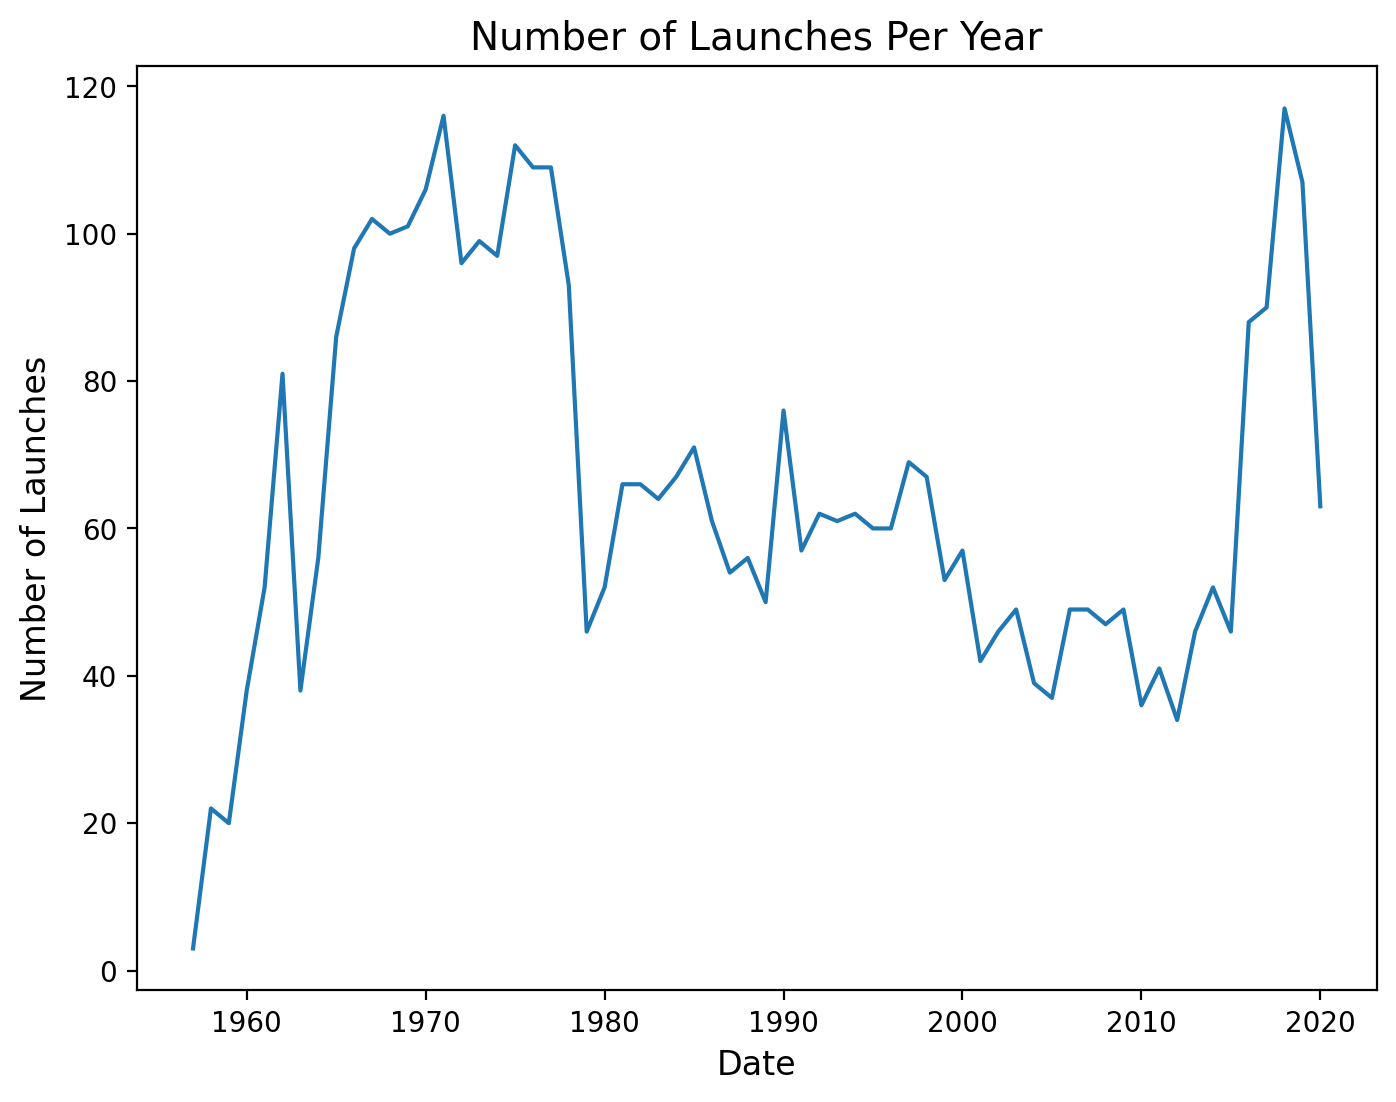

In [ ]:
#graph the number of launches per year
plt.figure(figsize=(8,6), dpi=200)

plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Launches', fontsize=12)
plt.title('Number of Launches Per Year', fontsize=14)

plt.plot(launch_per_year.Year, launch_per_year.Launches)
plt.show()

# Chart the Number of Launches Month-on-Month until the Present

Which month has seen the highest number of launches in all time? Superimpose a rolling average on the month on month time series chart.

In [ ]:
#create a new column for yearmonth data
date_df['YearMonth'] = date_df['Date'].dt.to_period('M')

#view data to confirm column was successfully added
date_df.head()

,Organisation,Location,Date,Detail,Rocket_Status,Mission_Status,Country,Country_Code,Year,YearMonth
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA",2020-08-07 05:12:00,Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,Success,USA,USA,2020,2020-08
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...",2020-08-06 04:01:00,Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,Success,China,CHN,2020,2020-08
2,SpaceX,"Pad A, Boca Chica, Texas, USA",2020-08-04 23:57:00,Starship Prototype | 150 Meter Hop,StatusActive,Success,USA,USA,2020,2020-08
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan",2020-07-30 21:25:00,Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,Success,Kazakhstan,KAZ,2020,2020-07
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA",2020-07-30 11:50:00,Atlas V 541 | Perseverance,StatusActive,Success,USA,USA,2020,2020-07


In [ ]:
date_df['YearMonth'].info()

<class 'pandas.core.series.Series'>
Index: 4198 entries, 0 to 4323
Series name: YearMonth
Non-Null Count  Dtype    
--------------  -----    
4198 non-null   period[M]
dtypes: period[M](1)
memory usage: 65.6 KB


In [ ]:
#Convert YearMonth to datetime object(e.g. timestamp representing the start of the month)
date_df['YearMonth'] = date_df['YearMonth'].dt.to_timestamp()

In [ ]:
date_df['YearMonth'].info()

<class 'pandas.core.series.Series'>
Index: 4198 entries, 0 to 4323
Series name: YearMonth
Non-Null Count  Dtype         
--------------  -----         
4198 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 65.6 KB


In [ ]:
#cheack for NAN values in the monthyear column
date_df['YearMonth'].isna().values.sum()

np.int64(0)

In [ ]:
#create a dataframe that contains the number of launches month to month
launch_month_to_month = date_df.groupby('YearMonth').size().reset_index(name='Launches')
launch_month_to_month = launch_month_to_month.sort_values('YearMonth')
launch_month_to_month

,YearMonth,Launches
0,1957-10-01,1
1,1957-11-01,1
2,1957-12-01,1
3,1958-02-01,2
4,1958-03-01,3
...,...,...
742,2020-04-01,5
743,2020-05-01,9
744,2020-06-01,7
745,2020-07-01,14


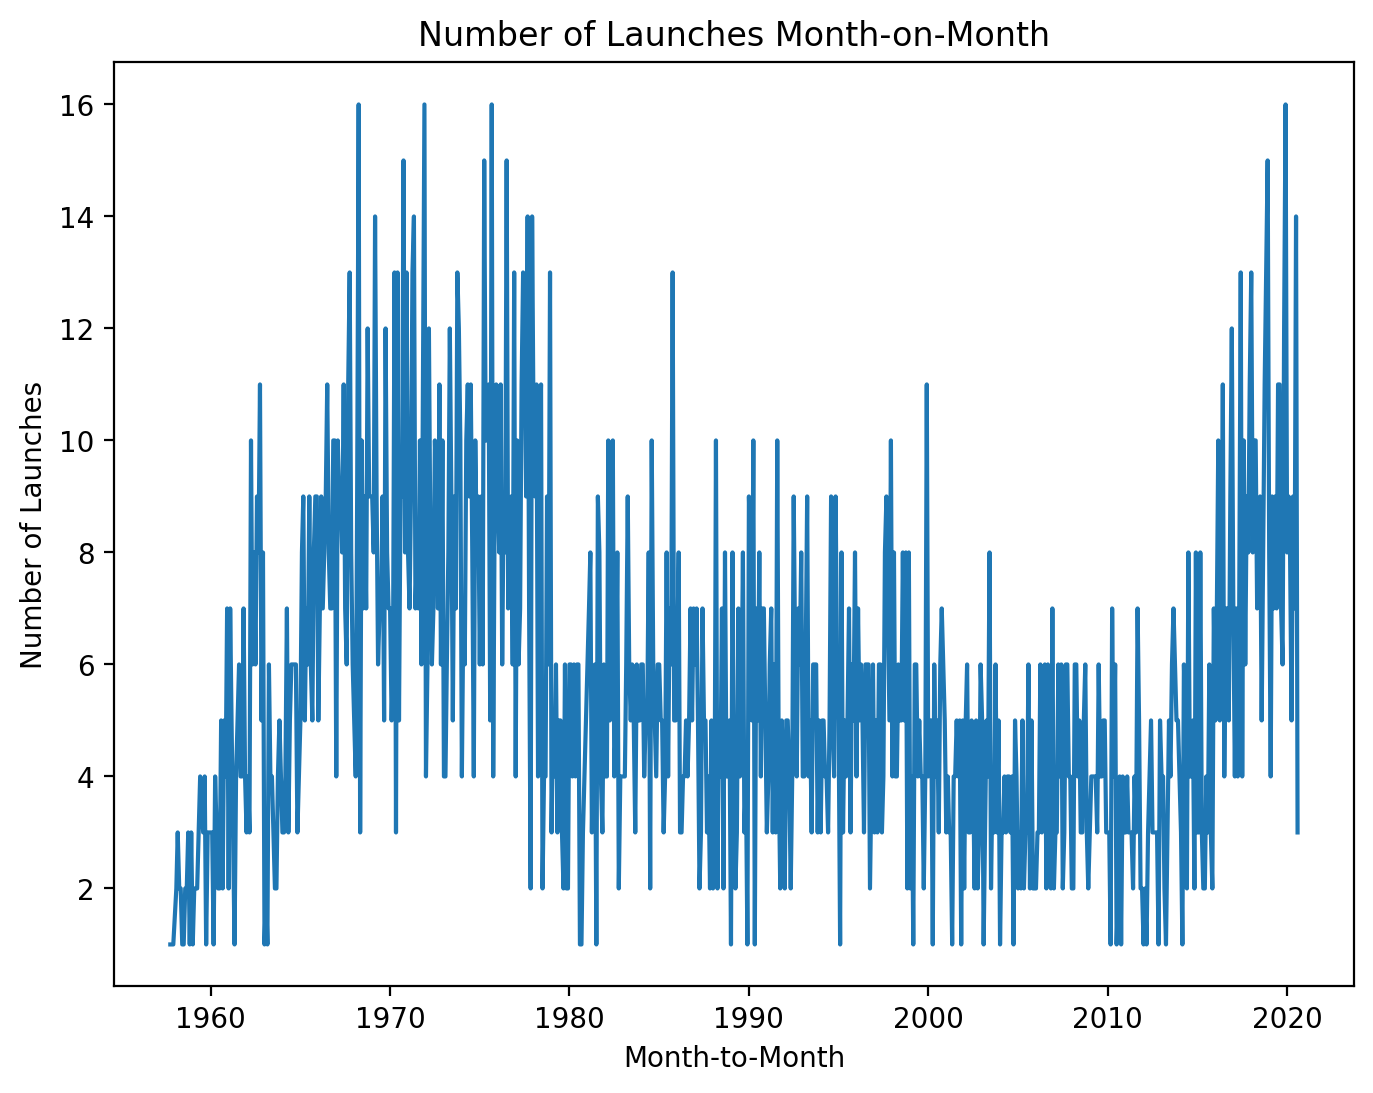

In [ ]:
#Graph the Number of Launches Month-on-Month until the Present
plt.figure(figsize=(8,6), dpi=200)

plt.xlabel('Month-to-Month')
plt.ylabel('Number of Launches')
plt.title('Number of Launches Month-on-Month')

plt.plot(launch_month_to_month.YearMonth, launch_month_to_month.Launches)

plt.show()

In [ ]:
#calculate the rolling mean for the number of launches month-to-month
rolling_month = launch_month_to_month['Launches'].rolling(window=6).mean()

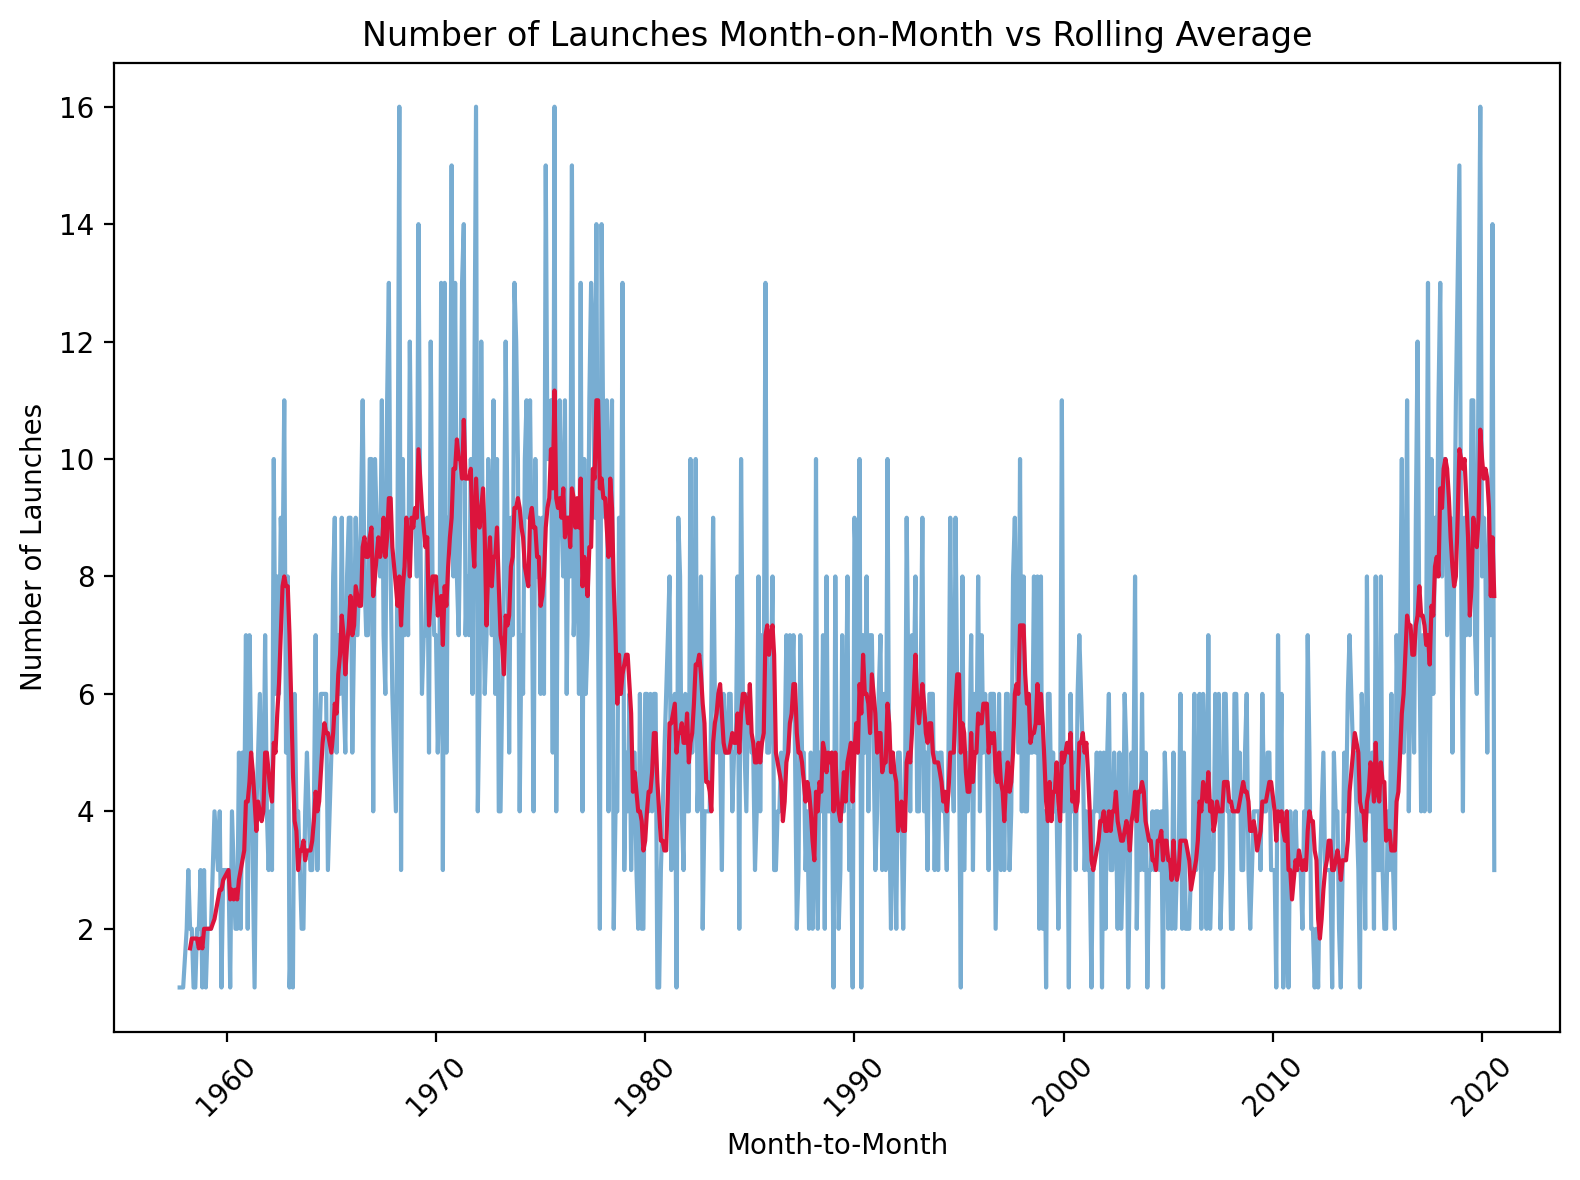

In [ ]:
#Graph the Number of Launches Month-on-Month until the Present and superimpose a rolling average on the month on month time series

plt.figure(figsize=(8,6), dpi=200)

plt.xlabel('Month-to-Month')
plt.ylabel('Number of Launches')
plt.title('Number of Launches Month-on-Month vs Rolling Average')

plt.plot(launch_month_to_month.YearMonth, launch_month_to_month.Launches, alpha=0.6)
plt.plot(launch_month_to_month.YearMonth, rolling_month, color='crimson')


plt.xticks(rotation=45)   # rotate labels for readability
plt.tight_layout()


plt.show()

# Launches per Month: Which months are most popular and least popular for launches?

Some months have better weather than others. Which time of year seems to be best for space missions?

In [ ]:
# Extract full month name directly from the Date column and create a new column "Month_Name"
date_df['Month_Name'] = date_df['Date'].dt.strftime('%B')

In [ ]:
#check Month_Name column for NAN values
date_df['Month_Name'].isna().values.sum()

np.int64(0)

In [ ]:
#print 30 random rows to check that the Month_Name column formatting was successful
date_df.sample(30)

,Organisation,Location,Date,Detail,Rocket_Status,Mission_Status,Country,Country_Code,Year,YearMonth,Month_Name
2295,General Dynamics,"SLC-3W, Vandenberg AFB, California, USA",1982-12-21 02:38:00,Atlas-E/F Star-37S-ISS | DMSP 5D-2/F6,StatusRetired,Success,USA,USA,1982,1982-12-01,December
847,NASA,"LC-39A, Kennedy Space Center, Florida, USA",2007-10-23 03:38:00,Space Shuttle Discovery | STS-120,StatusRetired,Success,USA,USA,2007,2007-10-01,October
1248,Boeing,"SLC-17B, Cape Canaveral AFS, Florida, USA",1999-06-10 13:48:00,Delta II 7420-10C | Globalstar 3,StatusRetired,Success,USA,USA,1999,1999-06-01,June
4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA",1958-02-01 03:48:00,Juno I | Explorer 1,StatusRetired,Success,USA,USA,1958,1958-02-01,February
3353,RVSN USSR,"Site 31/6, Baikonur Cosmodrome, Kazakhstan",1971-05-06 06:20:00,Voskhod | Cosmos 410,StatusRetired,Success,Kazakhstan,KAZ,1971,1971-05-01,May
2774,RVSN USSR,"Site 31/6, Baikonur Cosmodrome, Kazakhstan",1976-10-10 09:35:00,Soyuz U | Cosmos 859,StatusRetired,Success,Kazakhstan,KAZ,1976,1976-10-01,October
3164,RVSN USSR,"Site 41/1, Plesetsk Cosmodrome, Russia",1973-03-01 12:40:00,Voskhod | Cosmos 550,StatusRetired,Success,Russian Federation,RUS,1973,1973-03-01,March
3223,Martin Marietta,"SLC-4E, Vandenberg AFB, California, USA",1972-07-07 17:46:00,Titan IIID | KH-9 & SSF-B-23,StatusRetired,Success,USA,USA,1972,1972-07-01,July
3051,Martin Marietta,"SLC-4E, Vandenberg AFB, California, USA",1974-04-10 20:20:00,"Titan IIID | KH-9, SSF-B-25, IRCB",StatusRetired,Success,USA,USA,1974,1974-04-01,April
2934,Martin Marietta,"SLC-40, Cape Canaveral AFS, Florida, USA",1975-05-20 14:03:00,Titan III(23)C | DSCS-II 5&6,StatusRetired,Failure,USA,USA,1975,1975-05-01,May


In [ ]:
#Get the count of launches for each month
month_counts = date_df['Month_Name'].value_counts()
month_counts


,count
Month_Name,
December,430
June,386
October,375
April,366
August,358
September,354
March,349
July,347
November,325


In [ ]:
#Determine the most popular and the least popular month for launches
most_popular = month_counts.idxmax()
least_popular = month_counts.idxmin()
print(f"The most popular month for launches is {most_popular} ")
print(f"The least popular month for launches is {least_popular} ")

The most popular month for launches is December 
The least popular month for launches is January 


In [ ]:
#Determine the top 3 most popular and the top 3 least popular months for launches
Top_3_most_popular = month_counts.head(3).index.to_list()
print(f"The Top_3_most_popular months for lauches are {Top_3_most_popular}")

Top_3_least_popular = month_counts.tail(3).index.to_list()
print(f"The Top_3_least_popular months for lauches are {Top_3_least_popular}")

The Top_3_most_popular months for lauches are ['December', 'June', 'October']
The Top_3_least_popular months for lauches are ['February', 'May', 'January']


# How has the Launch Price varied Over Time?

Create a line chart that shows the average price of rocket launches over time.

In [ ]:
#create a new dataframe containing date and price
price_change_df = df_data[['Date','Price']].copy()

#clean price column by removing comma and converting to numeric
price_change_df['Price'] = price_change_df['Price'].astype(str).str.replace(",", "")
price_change_df['Price'] = pd.to_numeric(price_change_df['Price'], errors='coerce')

# Drop rows where Price is NaN
price_change_df = price_change_df.dropna(subset=['Price'])

In [ ]:
#remove UTC to standardize Date column
price_change_df['Date'] = price_change_df['Date'].astype(str).str.replace('UTC', '')

#covert Date column to datetime
price_change_df['Date'] = pd.to_datetime(price_change_df['Date'], errors='coerce')

#view column issue to confirm conversion
price_change_df['Date'].info()

<class 'pandas.core.series.Series'>
Index: 964 entries, 0 to 4020
Series name: Date
Non-Null Count  Dtype         
--------------  -----         
958 non-null    datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 15.1 KB


In [ ]:
#check for NAN values in Date column post conversion
price_change_df['Date'].isna().values.sum()

np.int64(6)

In [ ]:
#check for NAN values in Date column post conversion
price_change_df['Date'].isna().value_counts()

,count
Date,
False,958
True,6


In [ ]:
#Tried different formatting of Date column to try to mitigate data being converted to NAN post datetime conversion.
#Since could not find any solution even after research, will drop rows with NAN values
price_change_df = price_change_df.dropna(subset=['Date'])

#abstract only the year from the Date column and create a new column "year"
price_change_df['Year'] = price_change_df['Date'].dt.year

In [ ]:
#check for NAN values in the year column
price_change_df['Year'].isna().values.sum()

np.int64(0)

In [ ]:
#print 30 random rows to confirm the year column was successfully added and formatted
price_change_df.sample(30)

,Date,Price,Year
47,2020-02-19 21:07:00,29.75,2020
1290,1998-09-23 05:06:00,40.00,1998
1408,1997-01-12 09:27:00,450.00,1997
682,2011-07-08 15:29:00,450.00,2011
791,2008-11-15 00:55:00,450.00,2008
2233,1983-11-28 16:00:00,450.00,1983
371,2017-02-19 14:39:00,62.00,2017
466,2016-01-27 23:20:00,200.00,2016
713,2010-09-08 03:30:00,41.80,2010
870,2007-05-25 07:12:00,29.75,2007


In [ ]:
#get the total price of launches per year
price_change_time = price_change_df.groupby(['Year'], as_index=False).agg({'Price':'mean'})
price_change_time

,Year,Price
0,1964,63.23
1,1965,63.23
2,1966,59.00
3,1967,216.29
4,1968,279.20
5,1969,609.50
6,1970,"1,160.00"
7,1971,"1,160.00"
8,1972,"1,160.00"
9,1973,"1,160.00"


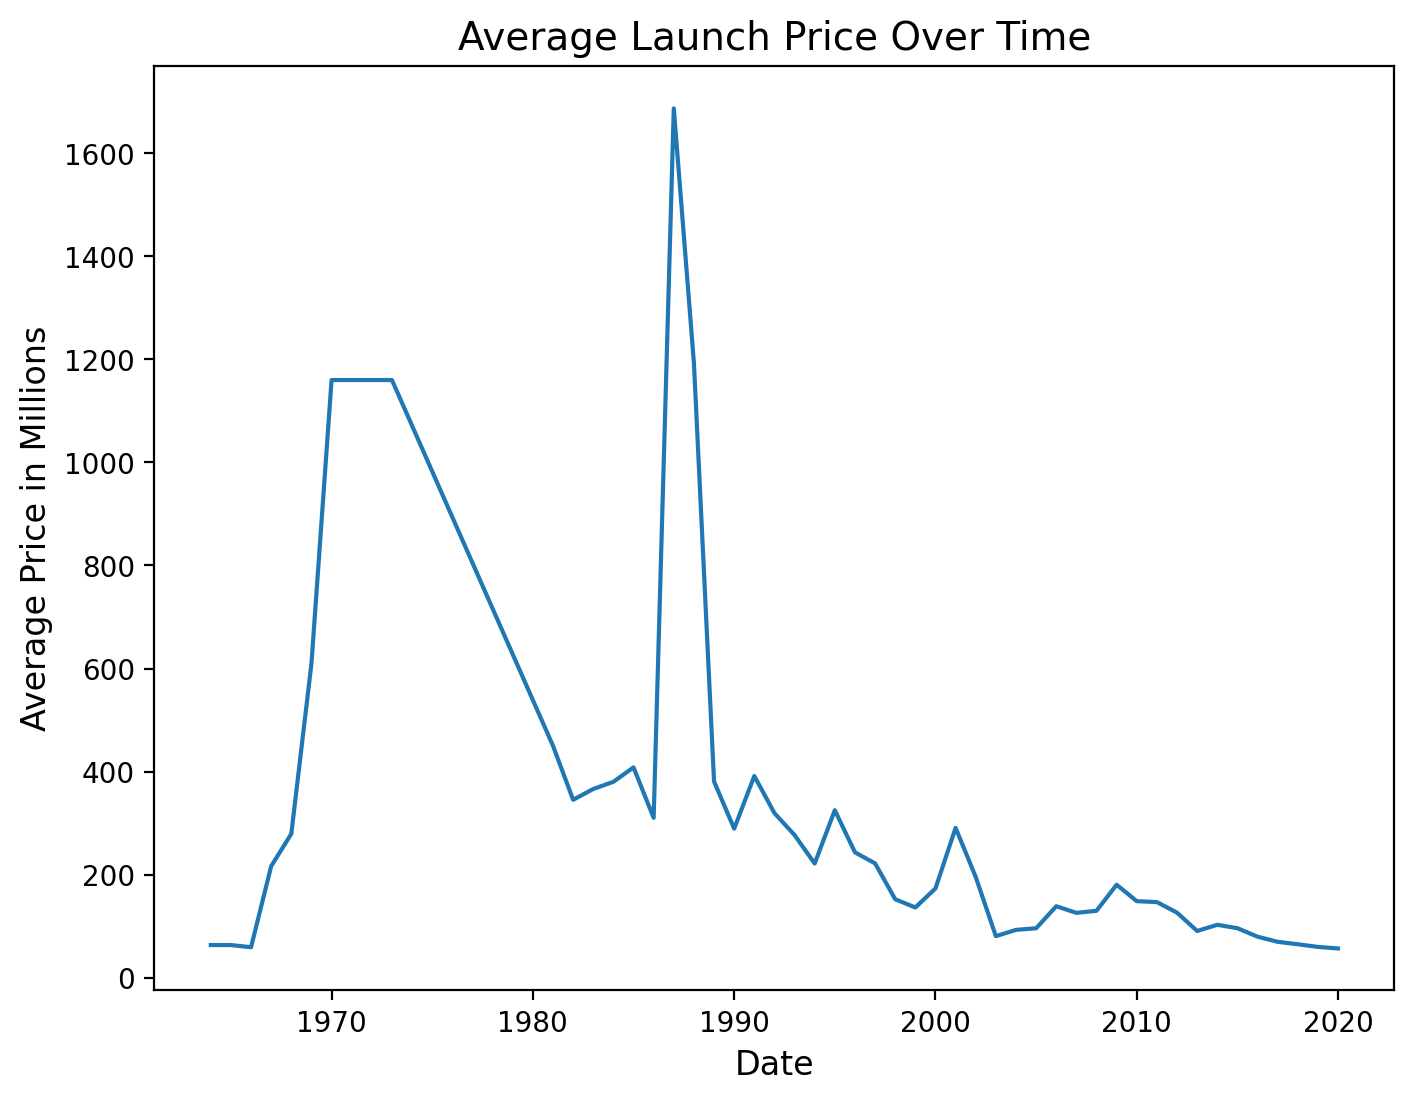

In [ ]:
#graph to show how launch price varied over time
plt.figure(figsize=(8,6), dpi=200)

plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Price in Millions', fontsize=12)
plt.title('Average Launch Price Over Time', fontsize=14)

plt.plot(price_change_time.Year, price_change_time.Price)
plt.show()

# Chart the Number of Launches over Time by the Top 10 Organisations.

How has the dominance of launches changed over time between the different players?

In [ ]:
#create a dataframe that contains the count of lauches over time by the top 10 organizations

#group data by organization and year
launch_count = date_df.groupby(['Organisation', 'Year']).size().reset_index(name='Launches')

#find the top ten organizations
top_ten_orgs = date_df['Organisation'].value_counts().nlargest(10).index

#filter data to include only the top ten organizations
launch_over_time = launch_count[launch_count['Organisation'].isin(top_ten_orgs)]

#view dataframe
launch_over_time

,Organisation,Year,Launches
9,Arianespace,1984,3
10,Arianespace,1985,4
11,Arianespace,1986,3
12,Arianespace,1987,2
13,Arianespace,1988,6
...,...,...,...
623,VKS RF,2016,4
624,VKS RF,2017,6
625,VKS RF,2018,5
626,VKS RF,2019,8


In [ ]:
#graph to show how launch price varied over time
plt.figure(figsize=(8,6), dpi=200)

graph = px.line(launch_over_time,
                x='Year',
                y='Launches',
                color='Organisation',
                title='Number of Launches over Time by the Top 10 Organisations')

graph.show()

<Figure size 1600x1200 with 0 Axes>

# Cold War Space Race: USA vs USSR

The cold war lasted from the start of the dataset up until 1991.

In [ ]:
#filter data to include data up to 1991
cold_war = date_df[date_df['Year']<= 1991]

#get launch count for the USA
usa_count = cold_war[cold_war['Country']=='USA'].shape[0]

#get launch count for the Russian Federation and Kazakhstan
ussr_count = cold_war[cold_war['Country'].isin(['Russian Federation', 'Kazakhstan'])].shape[0]

## Create a Plotly Pie Chart comparing the total number of launches of the USSR and the USA

Hint: Remember to include former Soviet Republics like Kazakhstan when analysing the total number of launches.

In [ ]:
#create a pie chart comparing the total number of launches of the USSR and the USA
pie_chart = px.pie(labels=['USA', 'USSR'], values=[usa_count, ussr_count], title='Cold War Space Race: USA vs USSR', names=['USA', 'USSR'])

pie_chart.show()

## Create a Chart that Shows the Total Number of Launches Year-On-Year by the Two Superpowers

/tmp/ipython-input-3378681071.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



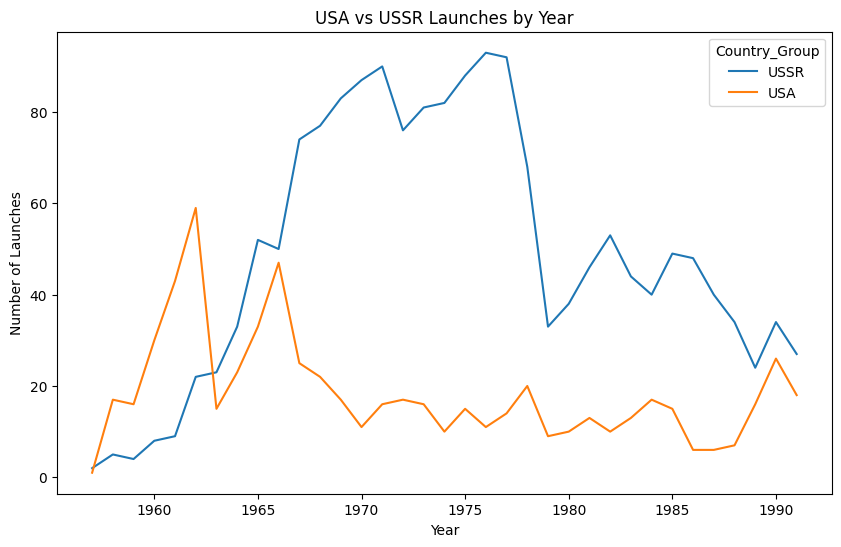

In [ ]:
# Create a new column that merges RUS and KAZ into a single group
cold_war['Country_Group'] = cold_war['Country_Code'].replace({'RUS': 'USSR', 'KAZ': 'USSR'})

# Group by Year and the new Country_Group column. "unstack" reshapes the data for plotting by pivoting the inner index level (Country_Group) into columns.
#"fill_value=0" replaces all missing values with 0, since not every year has launches from every country.
launch_counts = cold_war.groupby(['Year', 'Country_Group']).size().unstack(fill_value=0)


#ploy graph using matplotlib
ax = launch_counts[['USSR', 'USA']].plot(kind='line', figsize=(10, 6))

ax.set_ylabel("Number of Launches")
ax.set_title("USA vs USSR Launches by Year")

plt.show()



## Chart the Total Number of Mission Failures Year on Year.

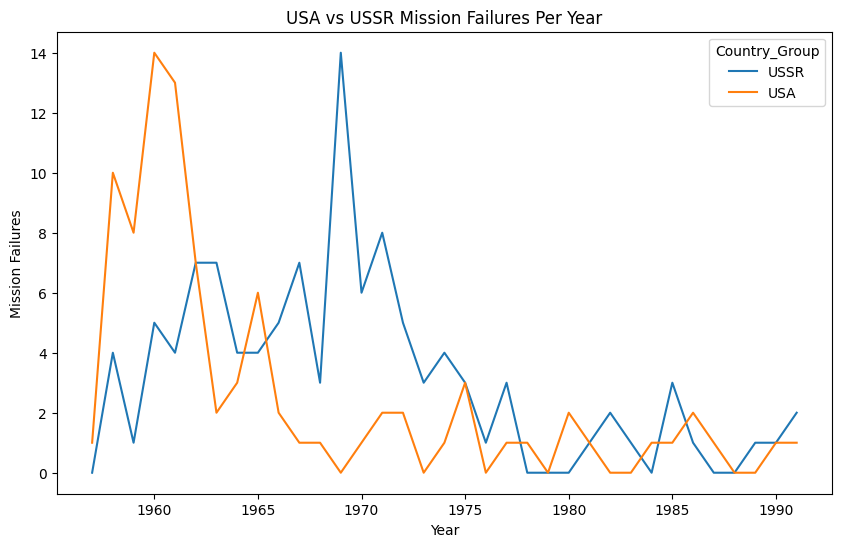

In [ ]:
#filter data to include only failed missions
mission_failures = cold_war[cold_war['Mission_Status']=="Failure"]

#group failures by year and country
failures_per_year = mission_failures.groupby(['Year', 'Country_Group']).size().unstack(fill_value=0)

#plot graph
ax = failures_per_year[['USSR', 'USA']].plot(kind='line', figsize=(10, 6))

ax.set_ylabel('Mission Failures')
ax.set_title('USA vs USSR Mission Failures Per Year')

plt.show()


## Chart the Percentage of Failures over Time

Did failures go up or down over time? Did the countries get better at minimising risk and improving their chances of success over time?

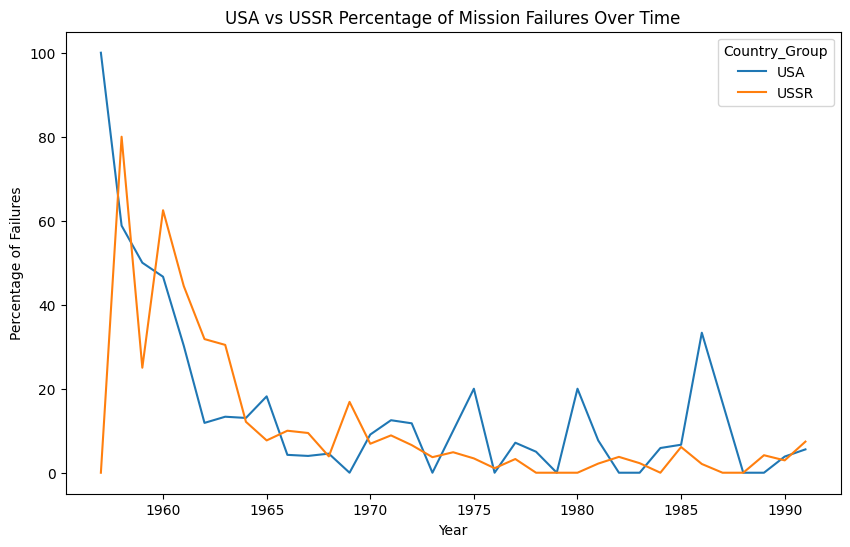

In [ ]:
#calculate the percentage of failures
failure_pct = (failures_per_year / launch_counts) * 100

#plot the graph
ax = failure_pct[['USA', 'USSR']].plot(kind='line', figsize=(10,6))

ax.set_ylabel('Percentage of Failures')
ax.set_title('USA vs USSR Percentage of Mission Failures Over Time')

plt.show()

# For Every Year Show which Country was in the Lead in terms of Total Number of Launches up to and including including 2020)

Do the results change if we only look at the number of successful launches?

/tmp/ipython-input-849769846.py:13: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



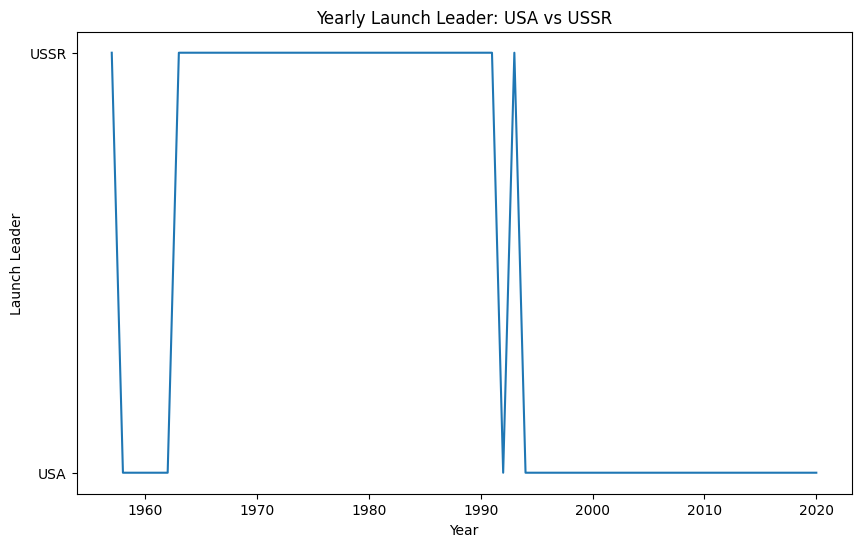

In [ ]:
# Create a new column that merges RUS and KAZ into a single group
date_df['Country_Group'] = date_df['Country_Code'].replace({'RUS': 'USSR', 'KAZ': 'USSR'})

# Group by Year and the new Country_Group column. "unstack" reshapes the data for plotting by pivoting the inner index level (Country_Group) into columns.
#"fill_value=0" replaces all missing values with 0, since not every year has launches from every country.
total_launch_counts = date_df.groupby(['Year', 'Country_Group']).size().unstack(fill_value=0)

#determine which country led each year
leader_by_year = total_launch_counts[['USA', 'USSR']].idxmax(axis=1)


# Convert country names to numeric codes for plotting
leader_numeric = leader_by_year.replace({'USA': 1, 'USSR': 2})

# Plot the numeric leader values
ax = leader_numeric.plot(kind='line', figsize=(10, 6))
ax.set_yticks([1, 2])
ax.set_yticklabels(['USA', 'USSR'])
ax.set_ylabel('Launch Leader')
ax.set_title('Yearly Launch Leader: USA vs USSR')

plt.show()



/tmp/ipython-input-1114100939.py:13: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



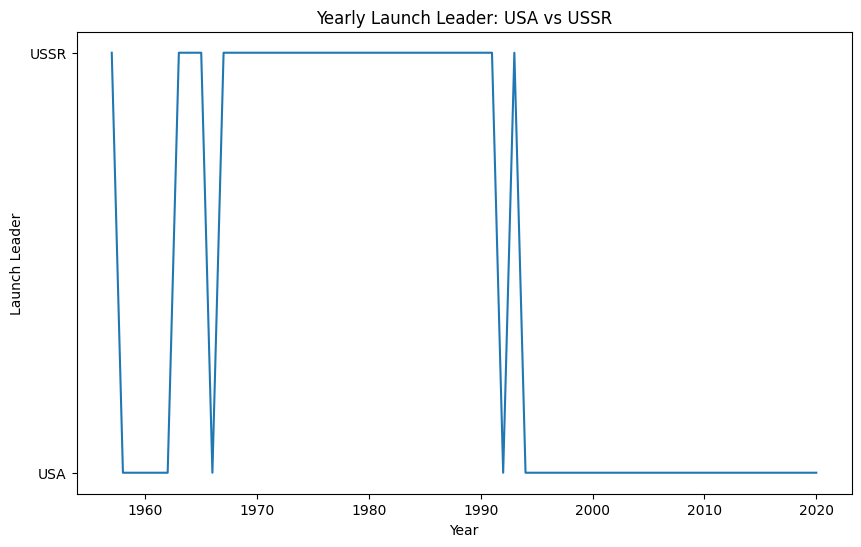

In [ ]:
#look at only successful launches
successful_missions = date_df[date_df['Mission_Status']=='Success']

# Group by Year and the new Country_Group column. "unstack" reshapes the data for plotting by pivoting the inner index level (Country_Group) into columns.
#"fill_value=0" replaces all missing values with 0, since not every year has launches from every country.
total_launch_counts = successful_missions.groupby(['Year', 'Country_Group']).size().unstack(fill_value=0)

#determine which country led each year
leader_by_year = total_launch_counts[['USA', 'USSR']].idxmax(axis=1)


# Convert country names to numeric codes for plotting
leader_numeric = leader_by_year.replace({'USA': 1, 'USSR': 2})

# Plot the numeric leader values
ax = leader_numeric.plot(kind='line', figsize=(10, 6))
ax.set_yticks([1, 2])
ax.set_yticklabels(['USA', 'USSR'])
ax.set_ylabel('Launch Leader')
ax.set_title('Yearly Launch Leader: USA vs USSR')

plt.show()



# Create a Year-on-Year Chart Showing the Organisation Doing the Most Number of Launches

Which organisation was dominant in the 1970s and 1980s? Which organisation was dominant in 2018, 2019 and 2020?

/tmp/ipython-input-1460102570.py:9: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



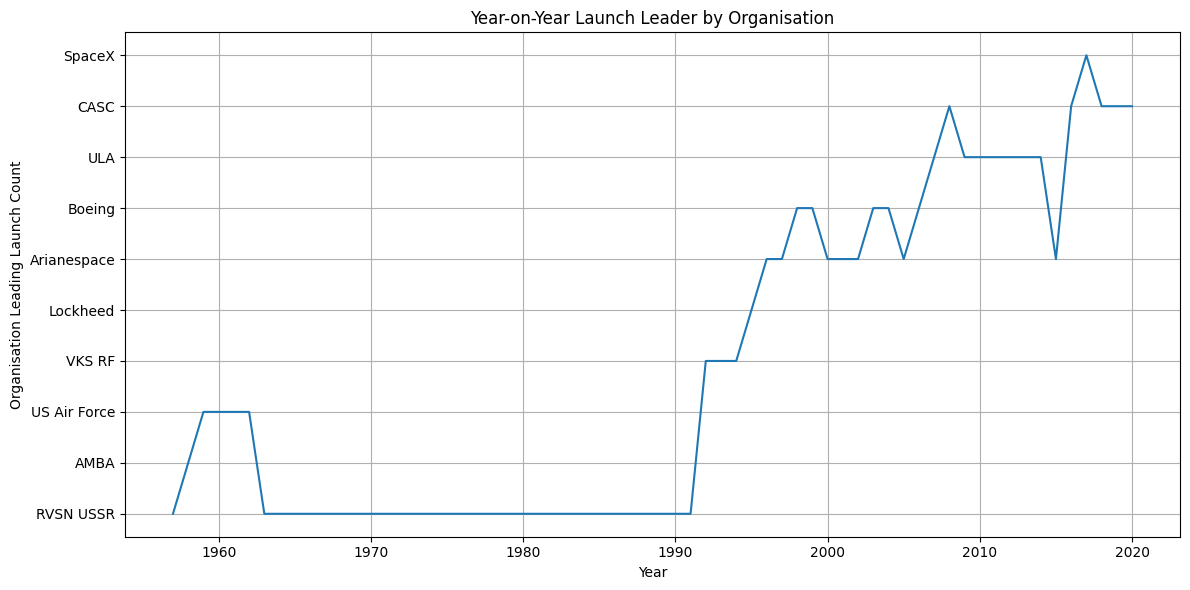

In [ ]:
#get launch count by organization
total_launches = date_df.groupby(['Year', 'Organisation']).size().unstack(fill_value=0)

#get the leading organization
leader_org_by_year = total_launches.idxmax(axis=1)

#Convert organisation names to numeric codes for plotting
org_codes = {org: i for i, org in enumerate(leader_org_by_year.unique(), start=1)}
leader_numeric = leader_org_by_year.replace(org_codes)


#plot the graph
ax = leader_numeric.plot(kind='line', figsize=(12, 6))

ax.set_yticks(list(org_codes.values()))
ax.set_yticklabels(list(org_codes.keys()))

ax.set_ylabel("Organisation Leading Launch Count")
ax.set_xlabel("Year")
ax.set_title("Year-on-Year Launch Leader by Organisation")

plt.grid(True)
plt.tight_layout()
plt.show()
